# Single-Example BrushNet Comparison

This notebook runs the same four implementations as the resumable BrushBench evaluation. Every method receives the same source, mask, prompt, and independent initial latent tensor.

In [6]:
from dataclasses import replace
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

# Set these paths before importing the inpainting modules.
BRUSHNET_ROOT = Path(os.environ.get(
    'BRUSHNET_ROOT',
    Path.home() / 'BrushNet',
))
# 
os.environ.setdefault('BRUSHNET_ROOT', str(BRUSHNET_ROOT))
os.environ.setdefault('BRUSHNET_BASE_MODEL', str(BRUSHNET_ROOT / 'checkpoints' / 'stable-diffusion-xl-base-1.0'))
os.environ.setdefault('BRUSHNET_MODEL', str(BRUSHNET_ROOT / 'checkpoints' / 'brushnet_sdxl'))
os.environ.setdefault('BRUSHBENCH_ROOT', str(ROOT / 'BrushBench'))

os.environ['BRUSHNET_MODEL_FAMILY'] = 'sdxl'

# os.environ['BRUSHNET_BASE_MODEL'] = (
#     'stabilityai/stable-diffusion-xl-base-1.0'
# )

# os.environ['BRUSHNET_MODEL'] = str(
#     BRUSHNET_ROOT / 'checkpoints' / 'brushnet_sdxl'
# )
EXAMPLE_KEY = '000000031'
SELECTED_METHODS = ['clean_ddim', 'cads', 'rho_star_pullback', 'tpso']
# SELECTED_METHODS = ['clean_ddim', 'tpso']
RESPONSE_REGION = 'edit_mask'  # use 'edit_mask' for the regional operator

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

from configs.inpainting import EXPERIMENT
from evaluation.inpainting_metrics import InpaintingMetrics
from inpainting import data, experiment, model

config = replace(EXPERIMENT, pullback_response_region=RESPONSE_REGION)
pipe = model.load_pipeline()
example = data.load_example(EXAMPLE_KEY)
sample = experiment.prepare_example(pipe, example, config)
metrics = InpaintingMetrics(device=str(pipe._execution_device))
print(example.key, example.prompt)
print('initial latents:', tuple(sample.initial_latents.shape))

/home/dehay/BrushNet/src/diffusers/models/lora.py:387: FutureWarning: `LoRACompatibleLinear` is deprecated and will be removed in version 1.0.0. Use of `LoRACompatibleLinear` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRACompatibleLinear", "1.0.0", deprecation_message)
/home/dehay/BrushNet/src/diffusers/models/lora.py:300: FutureWarning: `LoRACompatibleConv` is deprecated and will be removed in version 1.0.0. Use of `LoRACompatibleConv` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRACompatibleConv", "1.0.0", deprecation_message)
Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  5.28it/s]


000000031 a young girl holding a husky dog on a black background
initial latents: (5, 4, 128, 128)


## Prepare Method-Specific State

The pullback method computes its basis once before the shared sampler restarts. TPSO optimizes its token offsets before sampling.

In [8]:
basis = None
eigenvalues = None
optimized_tpso = None

if 'adaptive_pullback' in SELECTED_METHODS or 'rho_star_pullback' in SELECTED_METHODS:
    basis, eigenvalues = experiment.compute_initial_basis(
        pipe, sample, config, cache_dir=ROOT / 'outputs' / 'notebook_basis_cache'
    )
    print('pullback eigenvalues:', [round(float(x), 4) for x in eigenvalues[:8]])

if 'tpso' in SELECTED_METHODS:
    optimized_tpso = experiment.optimize_tpso(pipe, sample, config)
    print('TPSO steps:', optimized_tpso.steps_run)

pullback eigenvalues: [0.1163, 0.088, 0.0518, 0.0478, 0.0376, 0.0286, 0.0226, 0.0221]
TPSO 001/200: joint=1.9500 clean_cos=1.0000 pair_cos=1.0000
TPSO 010/200: joint=0.6718 clean_cos=0.8005 pair_cos=0.6668
TPSO 020/200: joint=0.6147 clean_cos=0.7909 pair_cos=0.6041
TPSO 030/200: joint=0.5878 clean_cos=0.7896 pair_cos=0.5779
TPSO 040/200: joint=0.5857 clean_cos=0.7881 pair_cos=0.5615
TPSO 050/200: joint=0.5691 clean_cos=0.7945 pair_cos=0.5644
TPSO 060/200: joint=0.5694 clean_cos=0.7971 pair_cos=0.5640
TPSO 070/200: joint=0.5573 clean_cos=0.7873 pair_cos=0.5419
TPSO 080/200: joint=0.5551 clean_cos=0.7935 pair_cos=0.5514
TPSO 090/200: joint=0.5515 clean_cos=0.7920 pair_cos=0.5464
TPSO 100/200: joint=0.5538 clean_cos=0.7864 pair_cos=0.5341
TPSO 110/200: joint=0.5513 clean_cos=0.7874 pair_cos=0.5346
TPSO 120/200: joint=0.5446 clean_cos=0.7884 pair_cos=0.5355
TPSO 130/200: joint=0.5456 clean_cos=0.7931 pair_cos=0.5438
TPSO 140/200: joint=0.5461 clean_cos=0.7943 pair_cos=0.5457
TPSO 150/200: 

In [9]:
images_by_method = {}
raw_by_method = {}
tpso_alpha_trace = None
rho_star_details = None

for method_name in SELECTED_METHODS:
    if method_name == 'clean_ddim':
        raw, blended = experiment.run_clean_ddim(pipe, sample, config)
    elif method_name == 'cads':
        raw, blended = experiment.run_cads(pipe, sample, config)
    elif method_name == 'adaptive_pullback':
        raw, blended = experiment.run_adaptive_pullback(
            pipe, sample, basis, config
        )
    elif method_name == 'rho_star_pullback':
        raw, blended, rho_star_details = experiment.run_rho_star_pullback(
            pipe, sample, basis, config, metrics
        )
    elif method_name == 'tpso':
        raw, blended, tpso_alpha_trace = experiment.run_tpso(
            pipe, sample, optimized_tpso, config
        )
    else:
        raise ValueError(f'unknown method: {method_name}')
    raw_by_method[method_name] = raw
    images_by_method[method_name] = blended

/home/dehay/miniforge3/envs/pullback/lib/python3.10/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


selected rhos: [1.0, 1.0, 2.0, 1.0, 1.0]
adaptive pullback refresh timesteps: [841, 661]


adaptive pullback:  14%|█▍        | 7/49 [00:04<00:28,  1.48it/s]

recomputing rank-10 pullback basis at t=841 from particle 0
intermediate pullback eigenvalues: ['0.0989', '0.0313', '0.0192', '0.00459', '0.00313', '0.00275', '0.00209', '0.0017']


adaptive pullback:  33%|███▎      | 16/49 [00:15<00:24,  1.33it/s]

recomputing rank-10 pullback basis at t=661 from particle 0
intermediate pullback eigenvalues: ['0.0672', '0.0333', '0.0212', '0.0182', '0.0122', '0.00826', '0.00732', '0.00652']


/home/dehay/miniforge3/envs/pullback/lib/python3.10/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/dehay/miniforge3/envs/pullback/lib/python3.10/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration.
/home/dehay/miniforge3/envs/pullback/lib/python3.10/site-packages/transformers/models/beit/image_processing_beit.py:108: FutureWarning: The `reduce_labels`

,method,lpips_mean,lpips_min,dino_sim_mean,dino_sim_max,vendi,clip,mss
0,clean_ddim,0.149492,0.103327,0.999285,0.999655,1.072191,40.383794,0.986920
1,cads,0.308039,0.125387,0.990540,0.999305,1.261655,39.319924,0.941212
2,rho_star_pullback,0.201697,0.131208,0.997644,0.998940,1.162256,40.913497,0.967539
3,tpso,0.158514,0.096114,0.999167,0.999655,1.098108,40.355727,0.980995


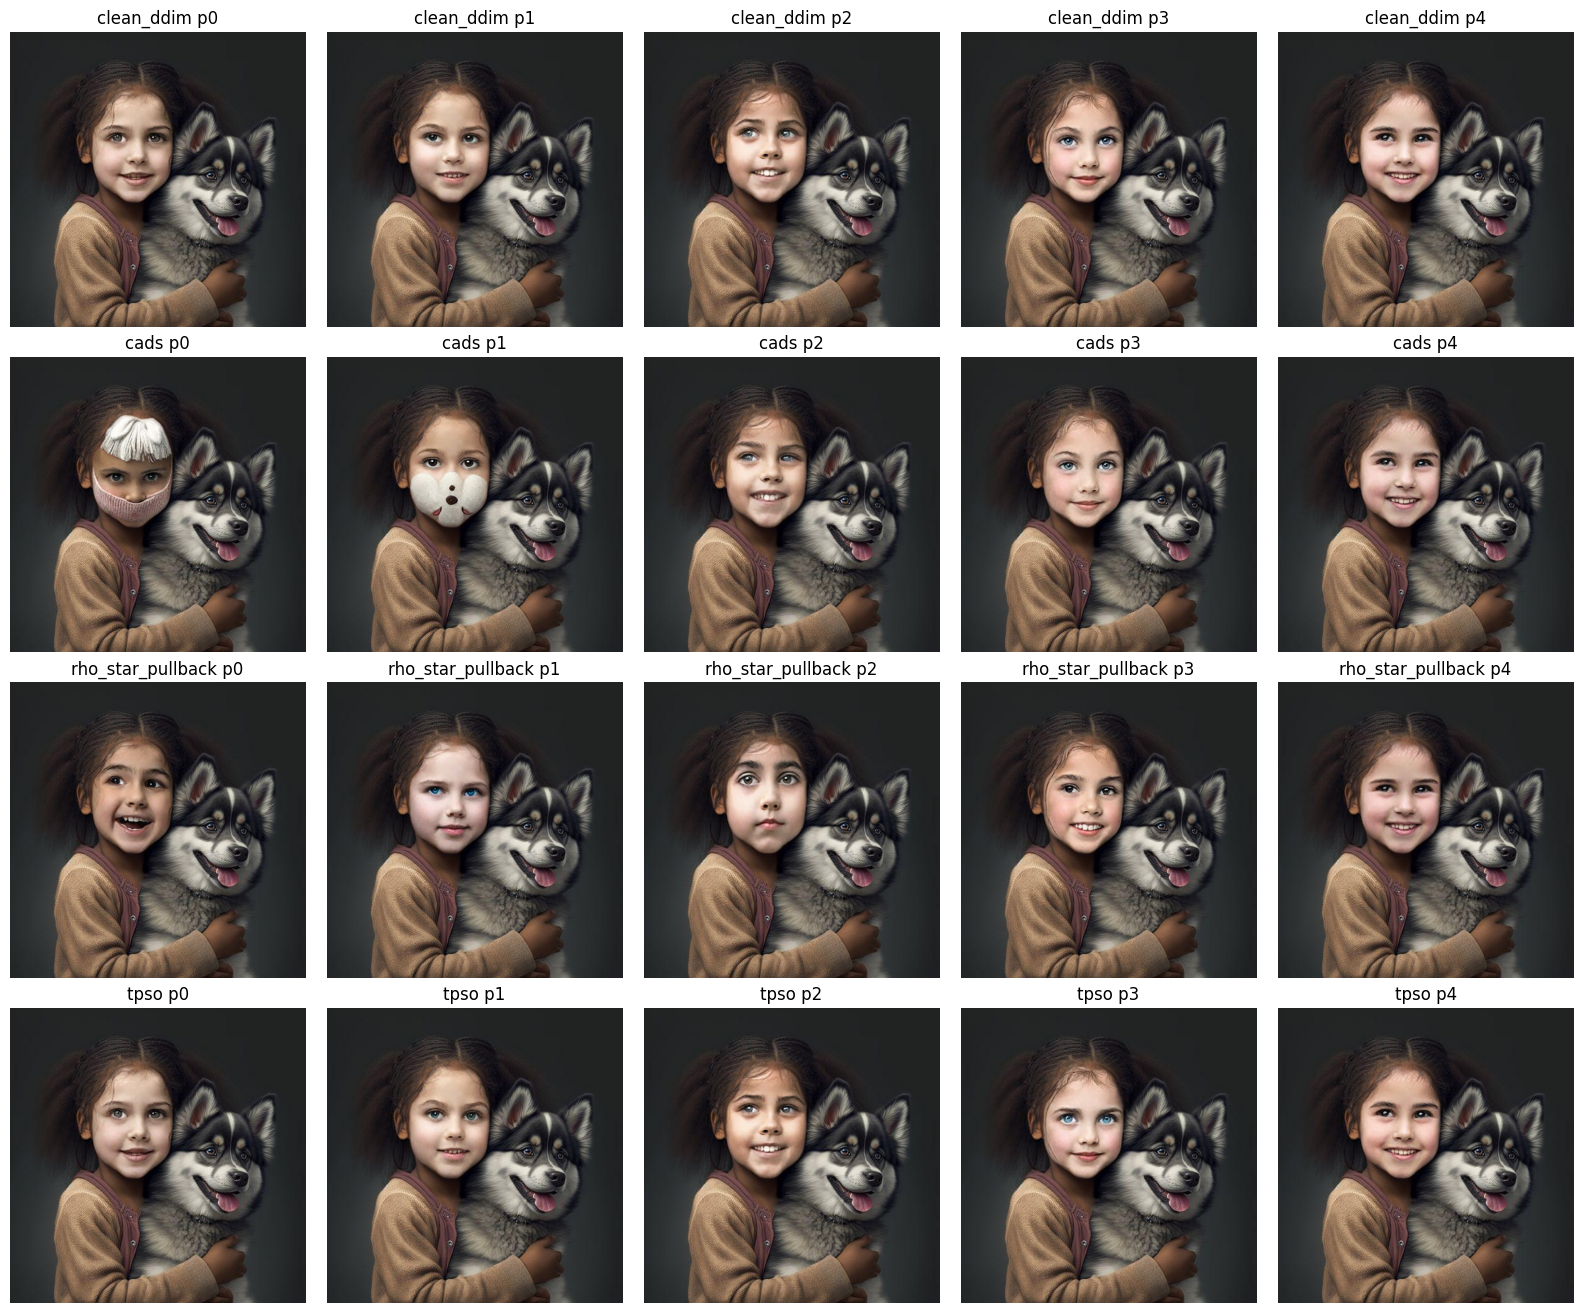

In [10]:
rows = []
for method_name, images in images_by_method.items():
    values = metrics.full_metrics(images, example.prompt, sample.edit_mask_image)
    rows.append({'method': method_name, **values})
display(pd.DataFrame(rows)[
    ['method', 'lpips_mean', 'lpips_min', 'dino_sim_mean',
     'dino_sim_max', 'vendi', 'clip', 'mss']
])

fig, axes = plt.subplots(
    len(images_by_method), config.num_particles,
    figsize=(3.2 * config.num_particles, 3.3 * len(images_by_method)),
    squeeze=False,
)
for row, (method_name, images) in enumerate(images_by_method.items()):
    for particle, image in enumerate(images):
        axes[row, particle].imshow(image)
        axes[row, particle].set_title(f'{method_name} p{particle}')
        axes[row, particle].axis('off')
plt.tight_layout()
plt.show()